# Análisis Exploratorio de Datos (EDA) — Galaxy10 DECaLS

En este cuaderno hacemos el primer contacto con el dataset antes de modelar. El objetivo
no es entrenar nada todavía, sino **conocer los datos**: cargarlos, comprobar que son
correctos y analizar cómo se reparten las imágenes entre las 10 clases morfológicas.

El dataset (`Galaxy10_DECals.h5`) contiene 17.736 imágenes de 256×256 píxeles en color
(bandas g, r, z) y sus etiquetas, generadas por consenso de voluntarios de Galaxy Zoo.

## 1. Carga de los datos

El dataset se distribuye como un único fichero **HDF5** (`.h5`), un formato que almacena
varios arrays con nombre dentro del mismo archivo, como si fuera un diccionario en disco.
Según la documentación oficial del dataset, contiene seis arrays alineados por posición
(la fila *i* de cada uno corresponde a la misma galaxia): `images` (los píxeles), `ans`
(la clase morfológica, 0–9), y `ra`, `dec`, `redshift` y `pxscale` (metadatos físicos).

Antes de cargar nada conviene **verificar** esa estructura en lugar de asumirla; lo hacemos
en la celda siguiente listando las claves del fichero. Una vez confirmada, separamos los
datos según su naturaleza:

- **Imágenes** → array de NumPy. Son tensores de 256×256×3, no datos tabulares, y es además
  el formato que espera PyTorch. No caben como columna de una tabla.
- **Metadatos escalares** (un valor por galaxia) → DataFrame de pandas, donde sí tiene
  sentido usar herramientas como `info()` y `describe()`.

La correspondencia imagen ↔ metadatos se mantiene por el **orden de las filas**, así que no
debemos reordenar un array sin el otro.

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Verificamos qué arrays contiene el fichero antes de asumir nada
RUTA = "../data/raw/Galaxy10_DECals.h5"

with h5py.File(RUTA, "r") as f:
    for clave in f.keys():
        print(f"{clave:<10} forma={f[clave].shape}, dtype={f[clave].dtype}")

ans        forma=(17736,), dtype=uint8
dec        forma=(17736,), dtype=float64
images     forma=(17736, 256, 256, 3), dtype=uint8
pxscale    forma=(17736,), dtype=float64
ra         forma=(17736,), dtype=float64
redshift   forma=(17736,), dtype=float64


### Descripción de las variables

El fichero contiene seis arrays, todos alineados por posición (la fila *i* es la misma
galaxia en todos). Distinguimos los **datos** (las imágenes) de los **metadatos** (información
adicional de cada galaxia):

| Variable   | Tipo        | Descripción |
|------------|-------------|-------------|
| `images`   | imagen      | Imagen de la galaxia, 256×256 píxeles y 3 canales. Los canales corresponden a las bandas fotométricas **g, r, z** del sondeo DECaLS (verde-azul, rojo e infrarrojo cercano), combinadas como una imagen en color. Valores `uint8` en el rango [0, 255]. |
| `ans`      | categórica  | Etiqueta morfológica de la galaxia, un entero de 0 a 9 (las 10 clases). Es la variable objetivo que el modelo debe predecir. |
| `ra`       | numérica    | *Ascensión recta*: coordenada celeste análoga a la longitud terrestre, en grados (0–360). Indica la posición este–oeste de la galaxia en el cielo. |
| `dec`      | numérica    | *Declinación*: coordenada celeste análoga a la latitud, en grados (−90 a +90). Indica la posición norte–sur en el cielo. |
| `redshift` | numérica    | *Corrimiento al rojo* (z): mide cuánto se ha estirado la luz de la galaxia hacia el rojo por la expansión del universo. Funciona como indicador de distancia: a mayor redshift, galaxia más lejana (y vista en una época más antigua del cosmos). |
| `pxscale`  | numérica    | *Escala de píxel*: cuántos segundos de arco del cielo abarca cada píxel (arcsec/píxel). Relaciona el tamaño en píxeles de la imagen con el tamaño angular real de la galaxia. El valor nativo de DECam es 0,262 arcsec/píxel. |

En este proyecto **solo usamos `images` como entrada y `ans` como objetivo**. Los demás son
metadatos contextuales: no alimentan al modelo, pero ayudan a caracterizar el dataset
(por ejemplo, el rango de distancias de las galaxias o la resolución de las imágenes).

In [3]:
with h5py.File(RUTA, "r") as f:
    imagenes = f["images"][:]                 # tensor (17736, 256, 256, 3)
    meta = pd.DataFrame({
        "clase":    f["ans"][:].astype(int),
        "ra":       f["ra"][:],
        "dec":      f["dec"][:],
        "redshift": f["redshift"][:],
        "pxscale":  f["pxscale"][:],
    })

## 2. Comprobación de cordura

Antes de analizar nada, confirmamos que las imágenes tienen la forma, el tipo y el rango
de valores que esperamos. Las dejamos en `uint8` (enteros 0–255): así las 17.736 imágenes
ocupan ~3,5 GB en RAM. Convertirlas todas a `float32` las llevaría a ~14 GB; en su lugar,
la conversión y la normalización se harán por lotes justo antes de entrenar.

In [4]:
print(f"Imágenes:  {imagenes.shape}, dtype={imagenes.dtype}, "
      f"rango=[{imagenes.min()}, {imagenes.max()}]")
print(f"Etiquetas: {meta['clase'].shape}, clases={np.unique(meta['clase'])}")

Imágenes:  (17736, 256, 256, 3), dtype=uint8, rango=[0, 255]
Etiquetas: (17736,), clases=[0 1 2 3 4 5 6 7 8 9]


## 3. Inspección de los metadatos

Aquí sí aprovechamos pandas. `info()` nos da tipos y valores nulos; `describe()` resume
las variables numéricas. El `redshift`, por ejemplo, da una idea de la distancia de las
galaxias, y `pxscale` (arcsec/píxel) de la escala física de cada imagen.

In [5]:
meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 17736 entries, 0 to 17735
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clase     17736 non-null  int64  
 1   ra        17736 non-null  float64
 2   dec       17736 non-null  float64
 3   redshift  17644 non-null  float64
 4   pxscale   17736 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 692.9 KB


In [6]:
meta.describe()

,clase,ra,dec,redshift,pxscale
count,17736.000000,17736.000000,17736.000000,17644.000000,17736.000000
mean,4.645129,189.562989,24.191918,0.077503,0.274113
std,2.827654,60.379543,19.758818,0.044693,0.055019
min,0.000000,0.007269,-19.053900,-0.000124,0.262000
25%,2.000000,154.696865,5.085785,0.046520,0.262000
50%,5.000000,188.007858,23.032271,0.073432,0.262000
75%,7.000000,225.333595,39.909690,0.103634,0.262000
max,9.000000,359.951249,69.767128,1.441647,0.524000


### Observaciones de los metadatos

De `info()` y `describe()` extraemos varios puntos relevantes:

- **Valores faltantes:** `redshift` tiene 17.644 valores de 17.736, es decir **92 galaxias
  sin redshift**. Es la única variable con datos ausentes. No nos afecta, porque el
  redshift no es una entrada del modelo (clasificamos solo a partir de la imagen).

- **Redshift:** la media (~0,077) indica que son galaxias relativamente cercanas. El máximo
  (1,44) es un valor atípico —a esa distancia apenas se resolvería la morfología— y el mínimo
  ligeramente negativo es esencialmente cero (ruido de medida).

## 4. Distribución de clases

In [7]:
CLASES = [
    "Disturbed", "Merging", "Round Smooth", "In-between Round Smooth",
    "Cigar Shaped Smooth", "Barred Spiral", "Unbarred Tight Spiral",
    "Unbarred Loose Spiral", "Edge-on without Bulge", "Edge-on with Bulge",
]

tabla = meta["clase"].value_counts().sort_index().rename("n_imagenes").to_frame()
tabla["clase"] = [CLASES[c] for c in tabla.index]
tabla["porcentaje"] = (100 * tabla["n_imagenes"] / len(meta)).round(1)
tabla = tabla[["clase", "n_imagenes", "porcentaje"]]
tabla

,clase,n_imagenes,porcentaje
clase,,,
0,Disturbed,1081,6.1
1,Merging,1853,10.4
2,Round Smooth,2645,14.9
3,In-between Round Smooth,2027,11.4
4,Cigar Shaped Smooth,334,1.9
5,Barred Spiral,2043,11.5
6,Unbarred Tight Spiral,1829,10.3
7,Unbarred Loose Spiral,2628,14.8
8,Edge-on without Bulge,1423,8.0


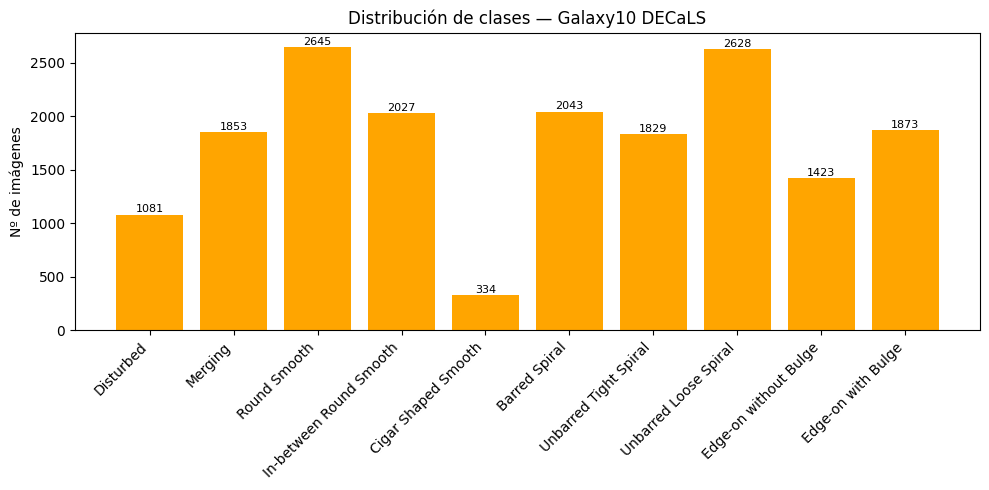

In [8]:
conteos = meta["clase"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(10), conteos, color="orange")
ax.set_xticks(range(10))
ax.set_xticklabels(CLASES, rotation=45, ha="right")
ax.set_ylabel("Nº de imágenes")
ax.set_title("Distribución de clases — Galaxy10 DECaLS")

for i, n in enumerate(conteos):
    ax.text(i, n + 20, str(n), ha="center", fontsize=8)

fig.tight_layout()
plt.show()

Contamos cuántas imágenes hay por clase. El dataset está **desbalanceado**: la clase 4
(Cigar Shaped) es minoritaria con diferencia. Esto importa porque la *accuracy* global
puede ser engañosa (un modelo que ignore las clases raras seguiría puntuando alto), así
que más adelante usaremos métricas robustas como el F1 macro y ponderación de clases.

## 5. Ejemplos de cada clase

Antes de ver las imágenes reales del dataset, esta guía resume qué caracteriza
visualmente a cada tipo morfológico y en qué hay que fijarse. El esquema siguiente
ilustra las 10 clases (formas idealizadas, no imágenes reales):

![Tipos morfológicos de galaxias](../reports/figures/tipos_galaxias.png)

Las 10 clases se agrupan en cuatro familias:

| Grupo | Clase | Nombre (traducción) | Qué buscar en la imagen |
|-------|:-----:|---------------------|-------------------------|
| **Suaves / elípticas** | 2 | Round Smooth (Suave redonda) | Mancha de luz lisa y casi circular, sin estructura interna; brillante en el centro y difuminada hacia los bordes. |
| | 3 | In-between Round Smooth (Suave intermedia) | Como la anterior pero algo achatada u ovalada, sin llegar a alargarse. |
| | 4 | Cigar Shaped Smooth (Suave alargada) | Mancha lisa claramente alargada, en forma de puro; sin brazos ni bulbo. |
| **Espirales (de frente)** | 5 | Barred Spiral (Espiral barrada) | Brazos espirales + una **barra recta** de estrellas cruzando el centro, de cuyos extremos parten los brazos. |
| | 6 | Unbarred Tight Spiral (Espiral apretada) | Brazos que salen directos del núcleo, muy enrollados y ceñidos; bulbo central grande. |
| | 7 | Unbarred Loose Spiral (Espiral abierta) | Brazos abiertos y separados, más desplegados; bulbo central pequeño. |
| **De canto** | 8 | Edge-on without Bulge (De canto sin bulbo) | El disco visto de lado: una línea fina y plana, sin abultamiento central. |
| | 9 | Edge-on with Bulge (De canto con bulbo) | Disco de canto con un **bulto central** evidente, como un platillo con una yema en medio. |
| **Anómalas** | 0 | Disturbed (Perturbada) | Forma deformada o asimétrica, sin estructura ordenada; a veces con "colas" de material. |
| | 1 | Merging (En fusión) | Dos galaxias o núcleos visibles juntos o conectados, en pleno choque. |

La diferencia clave entre **5 y 6/7** es la barra central; entre **6 y 7**, lo apretados
que estén los brazos; y entre **8 y 9**, la presencia o no del bulbo. Estas distinciones
finas son las que más cuesta separar, y previsiblemente las que el modelo más confundirá.

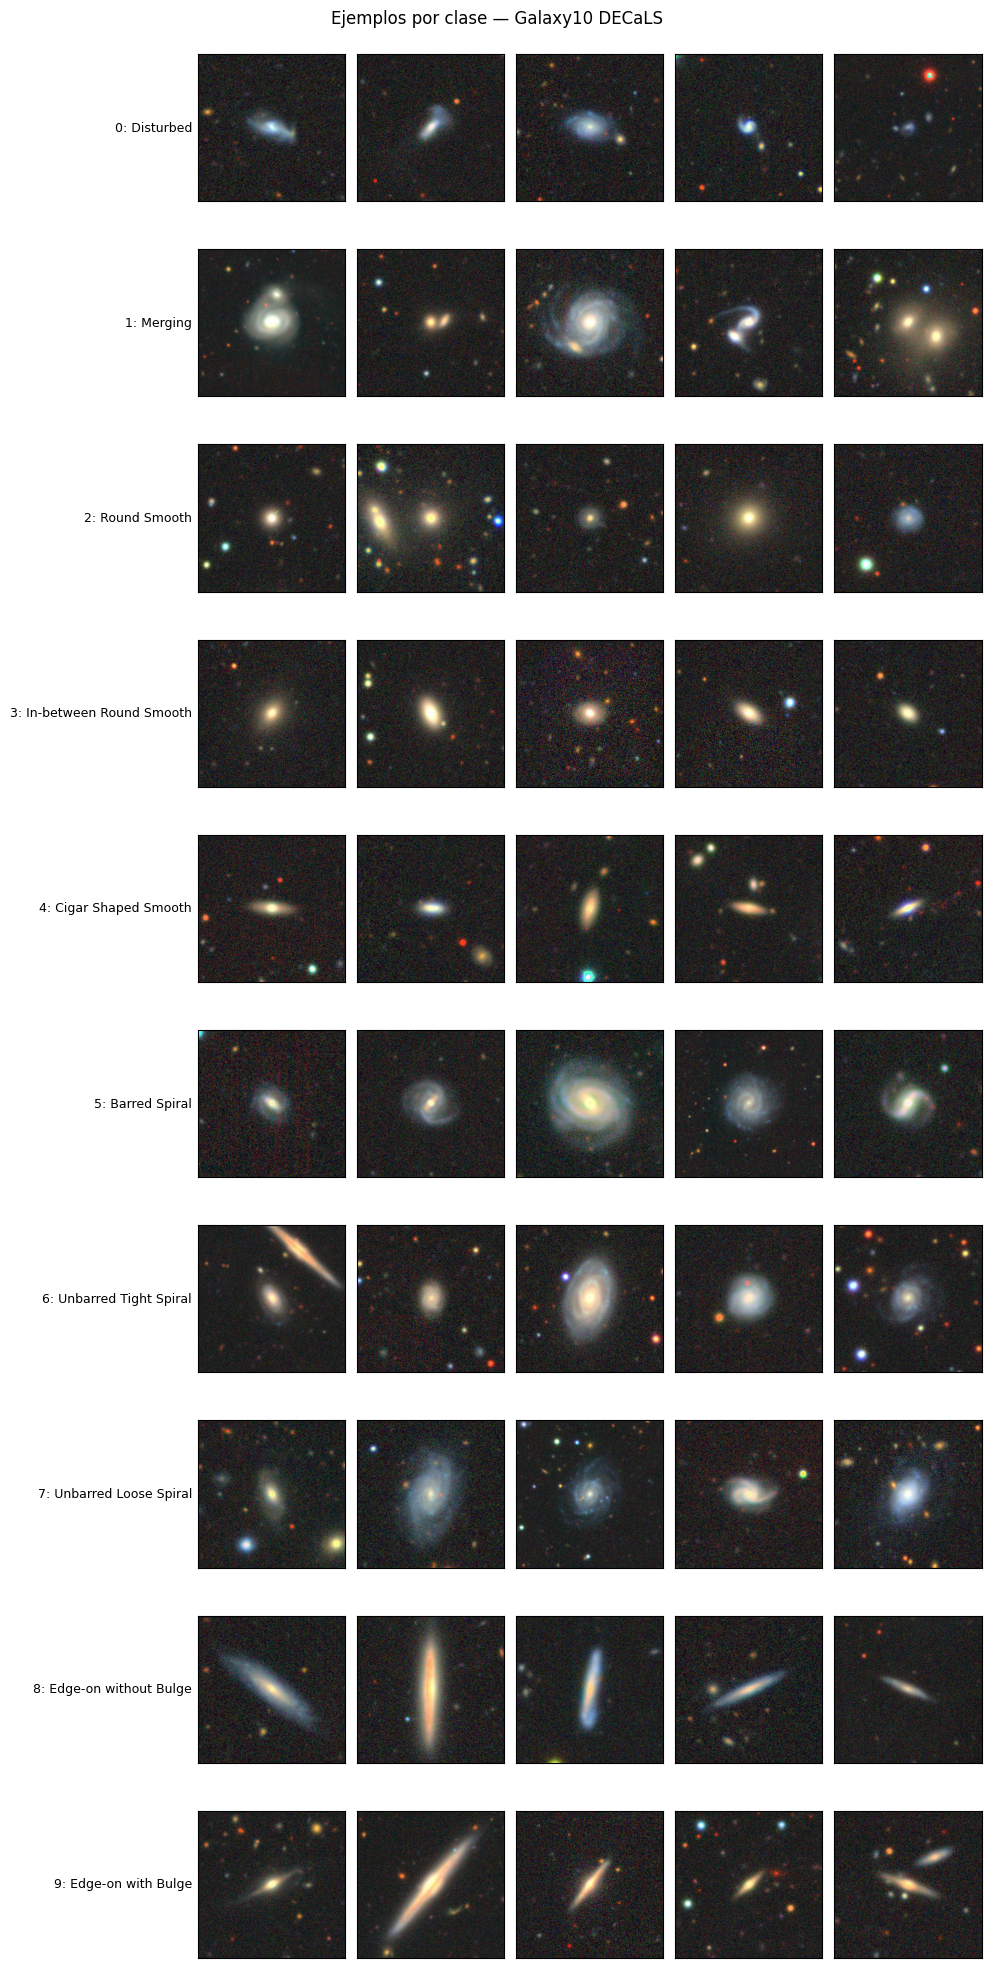

In [9]:
rng = np.random.default_rng(42)
n_por_clase = 5

fig, axes = plt.subplots(10, n_por_clase, figsize=(n_por_clase * 2, 20))
for c in range(10):
    indices = np.where(meta["clase"].values == c)[0]
    muestra = rng.choice(indices, size=n_por_clase, replace=False)
    for j, idx in enumerate(muestra):
        ax = axes[c, j]
        ax.imshow(imagenes[idx])
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(f"{c}: {CLASES[c]}", rotation=0, ha="right",
                          va="center", fontsize=9)

fig.suptitle("Ejemplos por clase — Galaxy10 DECaLS", y=0.99)
fig.tight_layout()
fig.savefig("../reports/figures/ejemplos_por_clase.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Distribución de intensidad por canal (g, r, z)

Cada imagen tiene tres canales correspondientes a las bandas fotométricas del sondeo.
Analizamos la distribución de intensidades de cada canal para ver cuánta señal real
hay frente al fondo de cielo, y cómo se comparan las bandas entre sí. Usamos escala
logarítmica en el eje Y porque, como veremos, los píxeles de fondo (intensidad ≈ 0)
son tan abundantes que en escala lineal aplastarían todo lo demás.

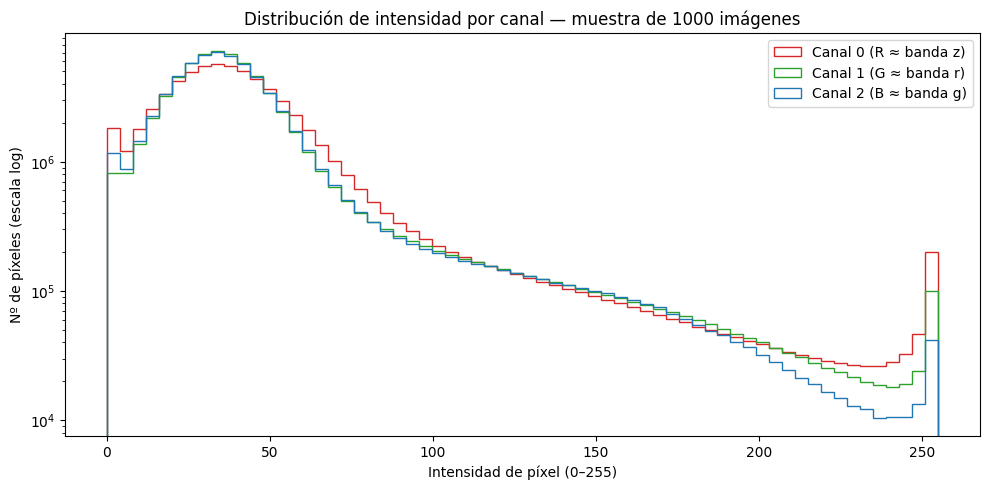

In [10]:
rng = np.random.default_rng(42)
idx_muestra = rng.choice(len(imagenes), size=1000, replace=False)   # muestra para que sea rápido
sub = imagenes[idx_muestra]

nombres_canal = ["Canal 0 (R ≈ banda z)", "Canal 1 (G ≈ banda r)", "Canal 2 (B ≈ banda g)"]
colores = ["tab:red", "tab:green", "tab:blue"]

fig, ax = plt.subplots(figsize=(10, 5))
for c in range(3):
    ax.hist(sub[:, :, :, c].ravel(), bins=64, range=(0, 255),
            histtype="step", color=colores[c], label=nombres_canal[c], log=True)
ax.set_xlabel("Intensidad de píxel (0–255)")
ax.set_ylabel("Nº de píxeles (escala log)")
ax.set_title("Distribución de intensidad por canal — muestra de 1000 imágenes")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/figures/histograma_canales.png", dpi=130, bbox_inches="tight")
plt.show()

In [11]:
stats_canales = pd.DataFrame({
    "media":   [imagenes[:, :, :, c].mean() for c in range(3)],
    "mediana": [np.median(imagenes[:, :, :, c]) for c in range(3)],
    "p95":     [np.percentile(imagenes[:, :, :, c], 95) for c in range(3)],
    "% fondo (<10)": [100 * (imagenes[:, :, :, c] < 10).mean() for c in range(3)],
}, index=["canal_0", "canal_1", "canal_2"]).round(2)
stats_canales

,media,mediana,p95,% fondo (<10)
canal_0,42.71,37.0,97.0,5.85
canal_1,41.47,36.0,95.0,3.40
canal_2,40.53,35.0,91.0,4.10


### Conclusiones del análisis por canal

- Los tres canales tienen brillos parecidos pero con un gradiente sistemático: el
  canal_0 es el más brillante (media 42,7; p95 97) y el canal_2 el más tenue
  (media 40,5; p95 91). Este orden es coherente con que el canal_0 corresponda a la
  banda más roja (z) y el canal_2 a la más azul (g): las galaxias, dominadas por
  poblaciones estelares viejas, suelen emitir más en el rojo. Adoptamos esa
  correspondencia (R≈z, G≈r, B≈g), inferida del brillo y no de los metadatos.

- El fondo no es negro puro: la mediana de intensidad ronda 35–37 y solo el 3–6 % de
  los píxeles caen por debajo de 10. Las imágenes son globalmente tenues, con la mayor
  parte de la señal entre ~35 y ~97 (sobre 255) y un cielo de fondo de nivel bajo.

## 7. Relación entre redshift y tipo morfológico

Cruzamos el redshift (indicador de distancia) con la clase para ver si los distintos
tipos de galaxia se encuentran a distancias distintas en este dataset. Excluimos los
valores atípicos en el gráfico para que no distorsionen la escala (vimos antes un
máximo de 1,44, muy alejado del resto).

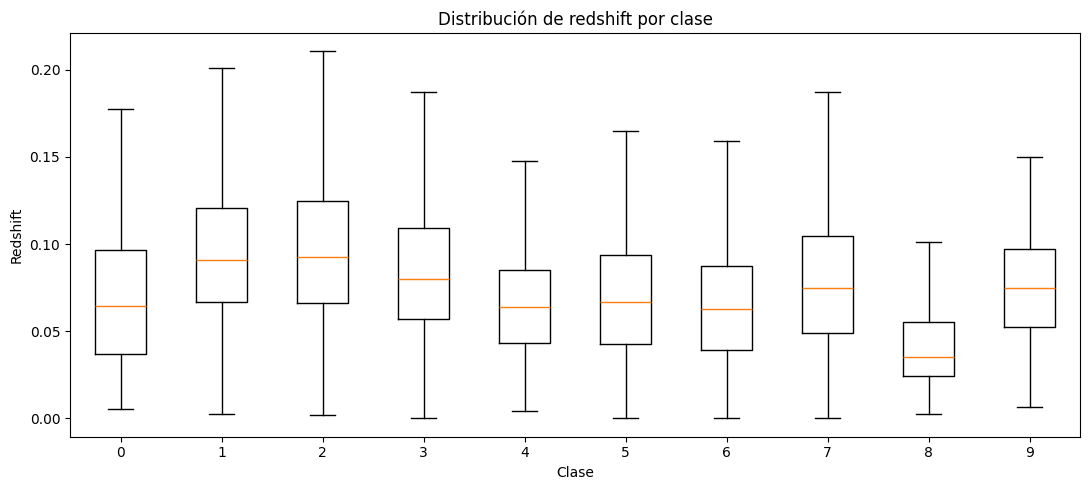

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
datos = [meta.loc[meta["clase"] == c, "redshift"].dropna() for c in range(10)]
ax.boxplot(datos, tick_labels=[str(c) for c in range(10)], showfliers=False)
ax.set_xlabel("Clase")
ax.set_ylabel("Redshift")
ax.set_title("Distribución de redshift por clase")
fig.tight_layout()
fig.savefig("../reports/figures/redshift_por_clase.png", dpi=130, bbox_inches="tight")
plt.show()

In [13]:
resumen = meta.groupby("clase")["redshift"].agg(["median", "mean", "count"]).round(4)
resumen.index = [CLASES[c] for c in resumen.index]
resumen

,median,mean,count
Disturbed,0.0647,0.0696,1073
Merging,0.0907,0.0938,1843
Round Smooth,0.0927,0.0948,2640
In-between Round Smooth,0.0796,0.0844,2022
Cigar Shaped Smooth,0.0639,0.0666,333
Barred Spiral,0.0664,0.0716,2034
Unbarred Tight Spiral,0.0625,0.0664,1823
Unbarred Loose Spiral,0.0748,0.0803,2614
Edge-on without Bulge,0.0353,0.0422,1396
Edge-on with Bulge,0.0749,0.0757,1866


### Conclusiones del análisis de redshift por clase

- El redshift mediano varía de forma notable entre clases: los tipos
  no se observan a la misma distancia típica.

- Las "Round Smooth" (clase 2) están entre las más lejanas, coherente
  con el efecto de selección: a más distancia, los rasgos finos (brazos, barra) dejan de
  resolverse y la galaxia tiende a clasificarse como suave.

- Las "Edge-on without Bulge" (clase 8) son, con diferencia, las más cercanas
  (mediana 0,035): identificar un disco fino de canto y sin bulbo exige que la galaxia
  esté cerca para resolver esa estructura.

- Implicación: parte de lo que el dataset etiqueta como "morfología" está influido por
  la distancia y la resolución, no solo por la física intrínseca. Es una limitación
  honesta a tener presente al interpretar los resultados del modelo.

## 8. Comprobación de integridad: imágenes duplicadas

Aunque el dataset está curado y publicado oficialmente, hacemos
una comprobación rápida de duplicados exactos como sanity check final. Comparamos cada
imagen mediante un hash de su contenido: si dos imágenes producen el mismo hash, son
idénticas píxel a píxel. Duplicados entre particiones serían un problema (fuga de datos),
así que conviene confirmar que no los hay.

In [14]:
import hashlib

# Calculamos un hash MD5 del contenido de cada imagen
hashes = [hashlib.md5(imagenes[i].tobytes()).hexdigest() for i in range(len(imagenes))]

n_unicos = len(set(hashes))
n_duplicados = len(hashes) - n_unicos
print(f"Imágenes totales:    {len(hashes)}")
print(f"Imágenes únicas:     {n_unicos}")
print(f"Duplicados exactos:  {n_duplicados}")

Imágenes totales:    17736
Imágenes únicas:     17675
Duplicados exactos:  61


In [15]:
from collections import Counter, defaultdict

grupos = defaultdict(list)
for i, h in enumerate(hashes):
    grupos[h].append(i)

dups = {h: idxs for h, idxs in grupos.items() if len(idxs) > 1}
clases_eda = meta["clase"].values

mismo = sum(1 for idxs in dups.values() if len(set(clases_eda[idxs])) == 1)
print(f"Grupos de duplicados: {len(dups)}")
print(f"Tamaños de grupo: {dict(Counter(len(idxs) for idxs in dups.values()))}")
print(f"Grupos con MISMA clase: {mismo}  |  con clases DISTINTAS: {len(dups) - mismo}")

Grupos de duplicados: 60
Tamaños de grupo: {2: 59, 3: 1}
Grupos con MISMA clase: 0  |  con clases DISTINTAS: 60


### Conclusiones de la comprobación de duplicados

La comprobación detectó **60 grupos de imágenes idénticas píxel a píxel** (59 grupos de 2
copias y 1 de 3): 121 imágenes implicadas. El dato relevante es que **los 60 grupos tienen
etiquetas de clase distintas entre sí** (0 grupos con la misma clase): la misma imagen
aparece repetida con clasificaciones morfológicas contradictorias.

No es, por tanto, simple redundancia, sino **ruido de etiquetado**: imágenes idénticas con
clases diferentes asignadas. Es coherente con la naturaleza del dataset (etiquetas por
consenso de voluntarios sobre galaxias visualmente ambiguas, donde el voto puede repartirse
entre clases vecinas). Con la información disponible no podemos determinar cuál es la
etiqueta correcta.

Decisión (aplicada en el cuaderno de pipeline): se eliminan **todas** las copias de estas
imágenes antes de entrenar. Conservar una copia con etiqueta arbitraria introduciría ruido
y, si cayera en validación o test, penalizaría injustamente al modelo. Coste: ~0,7 % del
dataset.